Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


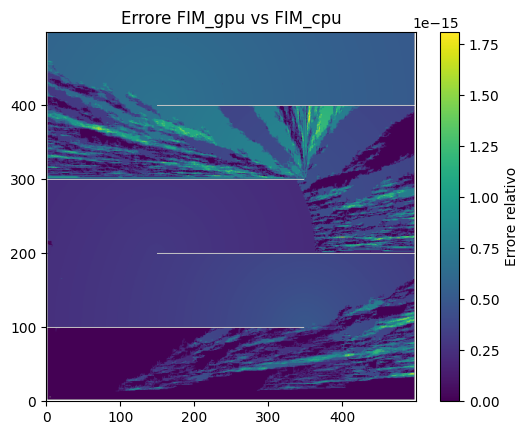

Errore totale: 9.02e-11


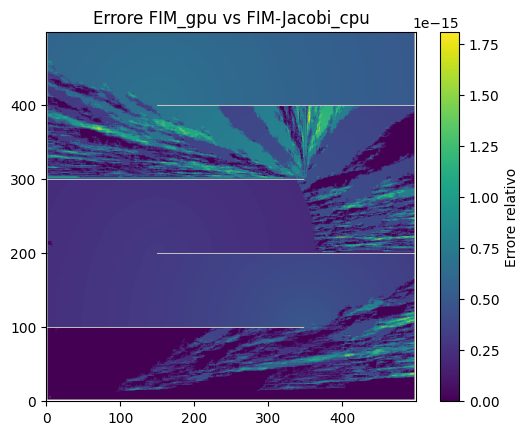

Errore totale: 9.02e-11


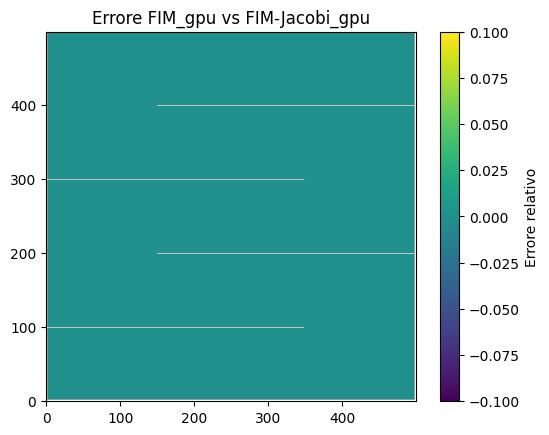

Errore totale: 0.00e+00


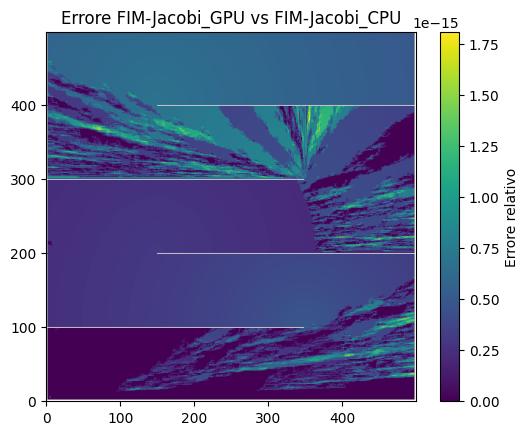

Errore totale: 9.02e-11


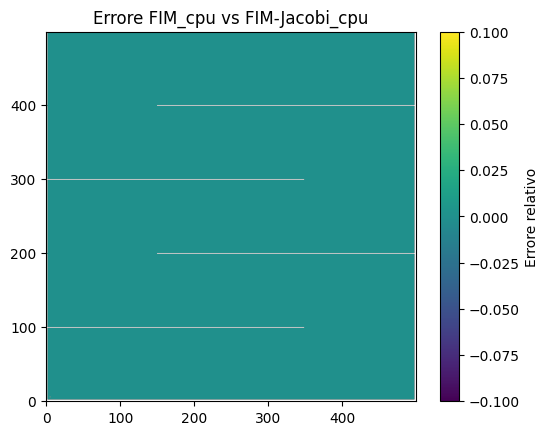

Errore totale: 0.00e+00


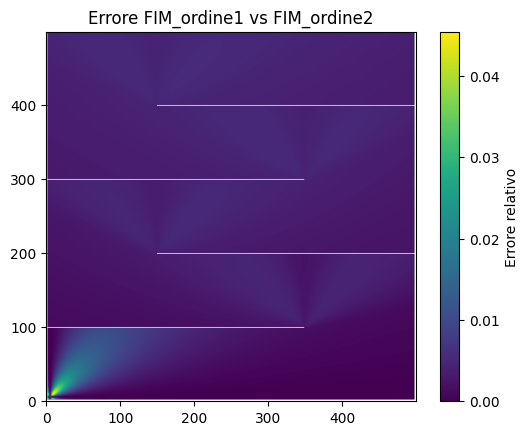

Errore totale: 9.11e+02


In [2]:
#confronto risultati#

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import animation, rc
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

nRows = 500
nCols = 500
#–––carico i dati dal drive–––––––––––––––––––––––––––––––––––
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'

T_fim_gpu        = np.load(path + 'T_fim_gpu.npz')['T_ref']
T_fim_cpu        = np.load(path + 'T_fim_cpu.npz')['T_FIMcpu']
T_senzalista_cpu = np.load(path + 'T_SenzaLista_cpu.npz')['T_SenzaListacpu']
T_senzalista_gpu = np.load(path + 'T_SenzaLista_gpu.npz')['T_SenzaLista_gpu']
T_fim_cpu_ordine2= np.load(path + 'T_fim_cpu_ordine2.npz')['T_FIMcpu_ordine2']

#–––confronto FIM parallelo e sequenzale––––––––––––––––––––––

mask1 = np.isfinite(T_fim_cpu) & np.isfinite(T_fim_gpu) & (T_fim_cpu != 0)

errore_pointwise = np.full_like(T_fim_cpu, np.nan)
errore_pointwise[mask1] = np.abs(T_fim_gpu[mask1] - T_fim_cpu[mask1]) / np.abs(T_fim_cpu[mask1])

errore_totale = np.sum(errore_pointwise[mask1])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM_gpu vs FIM_cpu')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")


#–––confrontof tra FIM parallelo e FIM senza lista sequenziale

mask2 = np.isfinite(T_fim_cpu) & np.isfinite(T_senzalista_gpu) & (T_fim_cpu != 0)

mask3 = np.isfinite(T_fim_cpu) & np.isfinite(T_senzalista_cpu) & (T_fim_cpu != 0)

errore_pointwise = np.full_like(T_fim_cpu, np.nan)
errore_pointwise[mask2] = np.abs(T_fim_gpu[mask3] - T_senzalista_cpu[mask3]) / np.abs(T_fim_cpu[mask3])

errore_totale = np.sum(errore_pointwise[mask3])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM_gpu vs FIM-Jacobi_cpu')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")

#–––confrontof tra FIM parallelo e FIM senza lista parallelo

errore_pointwise = np.full_like(T_fim_cpu, np.nan)
errore_pointwise[mask2] = np.abs(T_fim_gpu[mask2] - T_senzalista_gpu[mask2]) / np.abs(T_fim_cpu[mask2])

errore_totale = np.sum(errore_pointwise[mask2])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM_gpu vs FIM-Jacobi_gpu')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")

#–––confronto tra SenzaLista_gpu e SanzaLista_cpu––––

mask4 = np.isfinite(T_senzalista_gpu) & np.isfinite(T_senzalista_cpu) & (T_senzalista_cpu != 0)

errore_pointwise = np.full_like(T_senzalista_cpu, np.nan)
errore_pointwise[mask4] = np.abs(T_senzalista_gpu[mask4] - T_senzalista_cpu[mask4]) / np.abs(T_senzalista_gpu[mask4])

errore_totale = np.sum(errore_pointwise[mask4])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM-Jacobi_GPU vs FIM-Jacobi_CPU')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")

#–––confrontof tra FIM sequenziale e FIM senza lista sequenziale

mask5 = np.isfinite(T_fim_cpu) & np.isfinite(T_senzalista_cpu) & (T_fim_cpu != 0)

errore_pointwise = np.full_like(T_fim_cpu, np.nan)
errore_pointwise[mask5] = np.abs(T_fim_cpu[mask5] - T_senzalista_cpu[mask5]) / np.abs(T_fim_cpu[mask5])

errore_totale = np.sum(errore_pointwise[mask5])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM_cpu vs FIM-Jacobi_cpu')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")

#–––confrontof tra FIM sequenziale e FIM senza lista sequenziale

mask6 = np.isfinite(T_fim_cpu) & np.isfinite(T_fim_cpu_ordine2) & (T_fim_cpu != 0)

errore_pointwise = np.full_like(T_fim_cpu, np.nan)
errore_pointwise[mask5] = np.abs(T_fim_cpu[mask6] - T_fim_cpu_ordine2[mask6]) / np.abs(T_fim_cpu[mask6])

errore_totale = np.sum(errore_pointwise[mask6])

plt.figure()
plt.imshow(errore_pointwise, origin='lower')
plt.colorbar(label='Errore relativo')
plt.title('Errore FIM_ordine1 vs FIM_ordine2')
plt.show()

print(f"Errore totale: {errore_totale:.2e}")
